# 11 - Train YOLOv8

**Phase 3, Steps 3.1, 3.3, 3.4 - YOLO Setup, Training, and Evaluation**

Fine-tunes a pretrained YOLOv8 checkpoint on the 25-class detection dataset built in `10_YOLO_Dataset_Preparation.ipynb`, then evaluates mAP@0.5, mAP@0.5:0.95, precision, recall, and inference speed.

**Tip:** In Colab, go to Runtime > Change runtime type > GPU (T4) before running this notebook.

### 1. Install Ultralytics and mount Drive

In [1]:
!pip install -q datasets pyyaml tqdm scikit-learn matplotlib pandas opencv-python-headless ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os

# ---------------------------------------------------------------------------
# Project configuration - shared across every SmartVision AI notebook.
# All notebooks read/write under this same Google Drive folder so that
# work done in one notebook (e.g. dataset collection) is available to the
# next one (e.g. training), even across separate Colab sessions.
# ---------------------------------------------------------------------------
BASE_DIR = "/content/drive/MyDrive/SmartVisionAI"

RAW_DATA_DIR = os.path.join(BASE_DIR, "raw_data")
RAW_IMAGES_DIR = os.path.join(RAW_DATA_DIR, "images")
RAW_ANNOTATIONS_PATH = os.path.join(RAW_DATA_DIR, "annotations.json")

CLASSIFICATION_DIR = os.path.join(BASE_DIR, "classification")
CLASSIFICATION_TRAIN_DIR = os.path.join(CLASSIFICATION_DIR, "train")
CLASSIFICATION_VAL_DIR = os.path.join(CLASSIFICATION_DIR, "val")
CLASSIFICATION_TEST_DIR = os.path.join(CLASSIFICATION_DIR, "test")

DETECTION_DIR = os.path.join(BASE_DIR, "detection")
DETECTION_IMAGES_DIR = os.path.join(DETECTION_DIR, "images")
DETECTION_LABELS_DIR = os.path.join(DETECTION_DIR, "labels")
DETECTION_YAML_PATH = os.path.join(DETECTION_DIR, "data.yaml")

MODELS_DIR = os.path.join(BASE_DIR, "models")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")

for d in [BASE_DIR, RAW_DATA_DIR, RAW_IMAGES_DIR, CLASSIFICATION_DIR, DETECTION_DIR, MODELS_DIR, OUTPUTS_DIR]:
    os.makedirs(d, exist_ok=True)

# The 25 selected COCO classes (must match COCO category names exactly)
SELECTED_CLASSES = [
    # Vehicles (6)
    "car", "truck", "bus", "motorcycle", "bicycle", "airplane",
    # Person (1)
    "person",
    # Outdoor (3)
    "traffic light", "stop sign", "bench",
    # Animals (6)
    "dog", "cat", "horse", "bird", "cow", "elephant",
    # Kitchen & food (5)
    "bottle", "cup", "bowl", "pizza", "cake",
    # Furniture & indoor (4)
    "chair", "couch", "bed", "potted plant",
]
assert len(SELECTED_CLASSES) == 25

CLASS_TO_IDX = {name: i for i, name in enumerate(SELECTED_CLASSES)}
IDX_TO_CLASS = {i: name for i, name in enumerate(SELECTED_CLASSES)}

def safe_name(class_name):
    return class_name.replace(" ", "_")

IMAGES_PER_CLASS = 350        # -> 8,750 images total (up from 100/class to fight overfitting)
TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

CLS_IMG_SIZE = 224            # Classification input resolution (single-resolution throughout)
FINE_TUNE_IMG_SIZE = 384      # Unused by classifier training (reverted to single-resolution); kept for compatibility
YOLO_IMG_SIZE = 640
BATCH_SIZE = 32                # Stage 1 batch size
BATCH_SIZE_STAGE2 = 16         # Smaller batch at 384x384 to fit GPU memory (~2.9x pixels/image)

HF_DATASET_NAME = "detection-datasets/coco"

print("BASE_DIR:", BASE_DIR)
print("Classes:", len(SELECTED_CLASSES))


BASE_DIR: /content/drive/MyDrive/SmartVisionAI
Classes: 25


In [4]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


CUDA available: True
Device: Tesla T4


### 2. Load a pretrained YOLOv8 checkpoint

In [5]:
from ultralytics import YOLO

# yolov8n.pt = nano (fastest to train/run)
# yolov8s.pt = small (more accurate, still fast)
YOLO_BASE_WEIGHTS = "yolov8n.pt"
model = YOLO(YOLO_BASE_WEIGHTS)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### 3. Fine-tune on the 25-class subset

In [6]:
results = model.train(
    data=DETECTION_YAML_PATH,
    epochs=50,
    imgsz=YOLO_IMG_SIZE,
    batch=16,
    project=MODELS_DIR,
    name="yolo_smartvision",
    patience=10,
    optimizer="auto",
    exist_ok=True,
)

BEST_WEIGHTS_PATH = os.path.join(MODELS_DIR, "yolo_smartvision", "weights", "best.pt")
print("Best weights saved to:", BEST_WEIGHTS_PATH)


Ultralytics 8.4.100 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/SmartVisionAI/detection/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_smartvision, nbs=64, nms=False, opset=None, optimize=

### 4. Evaluate on the validation set

In [7]:
import json

eval_model = YOLO(BEST_WEIGHTS_PATH)
metrics = eval_model.val(data=DETECTION_YAML_PATH)

inference_ms = None
try:
    inference_ms = metrics.speed.get("inference")
except Exception:
    pass

summary = {
    "map50": float(metrics.box.map50),
    "map50_95": float(metrics.box.map),
    "precision": float(metrics.box.mp),
    "recall": float(metrics.box.mr),
    "inference_ms_per_image": inference_ms,
    "fps_estimate": round(1000 / inference_ms, 1) if inference_ms else None,
    "weights_path": BEST_WEIGHTS_PATH,
}

with open(os.path.join(OUTPUTS_DIR, "yolo_metrics.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("YOLO evaluation summary:")
print(f"  mAP@0.5      : {summary['map50']:.4f}  (target: >0.75)")
print(f"  mAP@0.5:0.95 : {summary['map50_95']:.4f}")
print(f"  Precision    : {summary['precision']:.4f}")
print(f"  Recall       : {summary['recall']:.4f}")
if summary["fps_estimate"]:
    print(f"  Est. FPS     : {summary['fps_estimate']}")


Ultralytics 8.4.100 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,010,523 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 71.1±13.1 MB/s, size: 184.5 KB)
val: Scanning /content/drive/MyDrive/SmartVisionAI/detection/labels/val.cache... 463 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 463/463 149.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 2.9it/s 10.2s
                   all        463       3164      0.603       0.47      0.489      0.316
                   car         90        313      0.526      0.485      0.478      0.296
                 truck         72        122        0.4      0.426      0.302      0.176
                   bus         41         55      0.702      0.727      0.746      0.576
            motorcycle         24         50      0.555       0.52      0.535      0.288
               bicyc

### 5. Visualize predictions on a few validation images

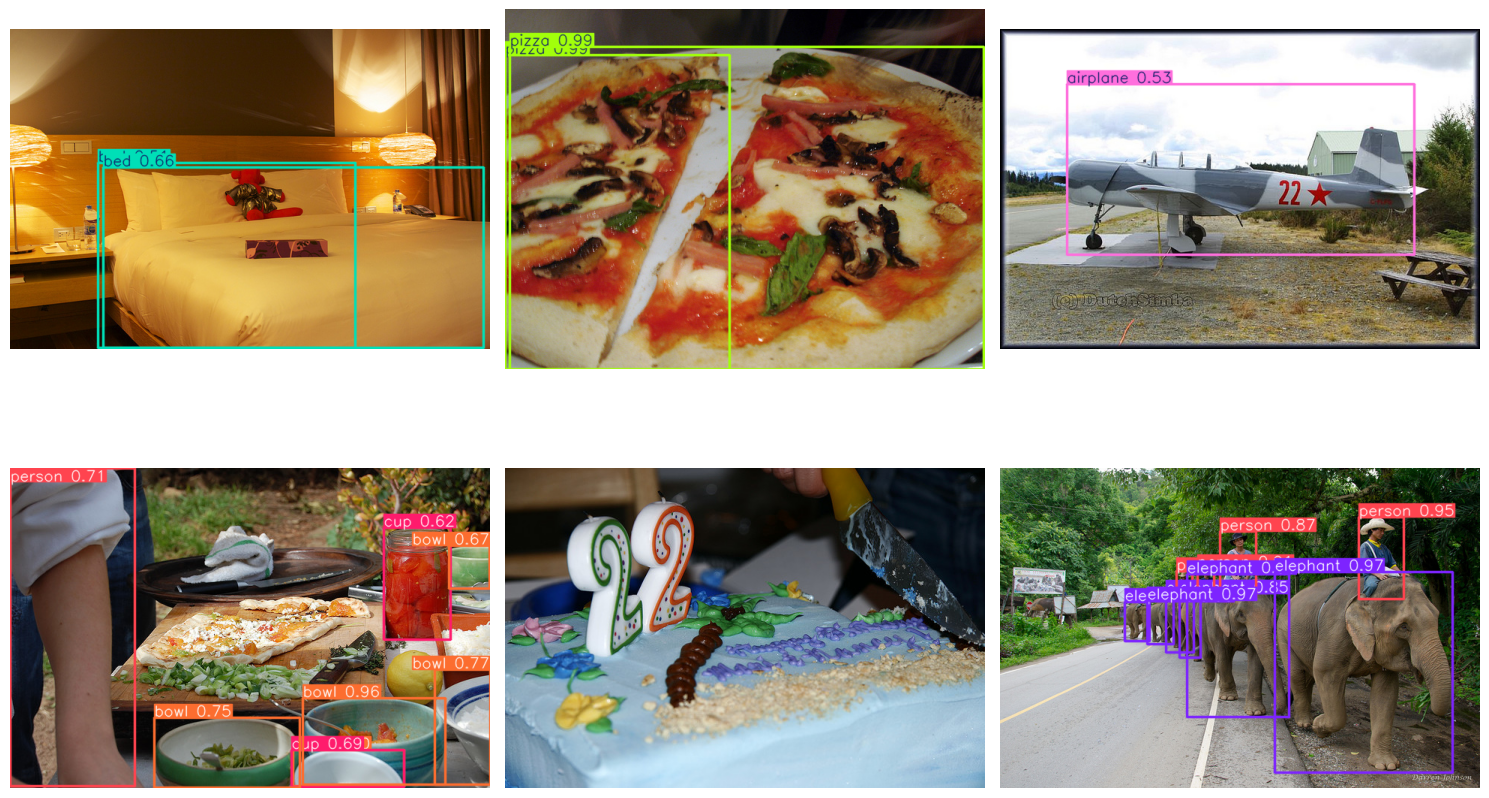

In [8]:
import glob
from PIL import Image
import matplotlib.pyplot as plt

val_images = glob.glob(os.path.join(DETECTION_IMAGES_DIR, "val", "*.jpg"))[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, img_path in zip(axes.flat, val_images):
    result = eval_model.predict(source=img_path, conf=0.5, verbose=False)[0]
    annotated = result.plot()  # returns a numpy array (BGR)
    ax.imshow(annotated[:, :, ::-1])  # BGR -> RGB
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "yolo_sample_predictions.png"), dpi=150)
plt.show()


**Next notebook:** `12_Inference_Pipeline_Demo.ipynb` chains this YOLO model with a trained classifier for the full detect-then-verify pipeline, before wiring both into the Streamlit app.